# Fase 5 — Modelos temporais de risco de defasagem

## tl;dr

Este notebook inicia a etapa preditiva com dois problemas distintos:

1. **Risco futuro:** o estudante estará defasado na PEDE seguinte observada?
2. **Incidência de nova defasagem:** entre quem não está defasado hoje, quem estará defasado na PEDE seguinte?

O treino usa 2022 para prever 2023; o teste temporal usa 2023 para prever 2024. Os resultados são uma linha de base auditável, não um modelo pronto para uso no aplicativo. O limiar operacional permanece uma decisão de negócio: o notebook mostra o trade-off, sem escolher um limiar de produção arbitrário.

## Contexto e método

**Fonte:** `data/processed/pede_painel_consolidado.csv`; contrato e linhagem em `docs/`.

### Premissas e controles

- Cada observação é um aluno-ano; `RA` é excluído das features.
- Nenhuma feature do ano seguinte é usada. `ANO` serve exclusivamente para separação temporal e também não entra no modelo.
- `INDE` e `PEDRA` são excluídos: INDE é composto pelos indicadores e Pedra tem regra pendente de reconciliação.
- `IPP`, `INDICADO` e `ATINGIU_PV` são excluídos por indisponibilidade estrutural em parte do período.
- A imputação mediana e a escala são ajustadas somente em 2022 dentro do pipeline.
- A avaliação reporta discriminação (ROC-AUC, PR-AUC), calibração (Brier) e operação (precisão, recall, F1, taxa de alerta e falsos negativos).
- Não há inferência causal nem escolha de limiar de produção nesta etapa.

In [1]:
from pathlib import Path
import sys

raiz = Path.cwd().resolve()
if raiz.name == "notebooks":
    raiz = raiz.parent
sys.path.append(str(raiz))

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

from src.modeling import (
    ALVO_INCIDENCIA,
    ALVO_RISCO_FUTURO,
    FEATURES_NUMERICAS,
    criar_baseline,
    criar_pipeline_logistico,
    calcular_metricas_operacionais,
    preparar_dataset_modelagem,
    separar_treino_teste_temporal,
    tabela_limiares,
)

painel = pd.read_csv(raiz / "data" / "processed" / "pede_painel_consolidado.csv")
print(f"Fonte: {raiz / 'data' / 'processed' / 'pede_painel_consolidado.csv'}")
print(f"Features ({len(FEATURES_NUMERICAS)}): {', '.join(FEATURES_NUMERICAS)}")

Fonte: /Users/sabrina/Documents/Cursos/FIAP/PósTech-DataAnalytics-2026/Fase5 /TCF5/tech-challenge-passos-magicos/data/processed/pede_painel_consolidado.csv
Features (14): FASE, FASE_IDEAL, DEFASAGEM_CALCULADA, IAN, IDA, IEG, IAA, IPS, IPV, NOTA_MATEMATICA, NOTA_PORTUGUES, NOTA_INGLES, IDADE_ANOS, ANO_INGRESSO


## Dados

A tabela confirma tamanho, prevalência e cobertura temporal antes do treino. O conjunto de incidência é menor porque exclui alunos já defasados no ano atual.

In [2]:
resumo_dados = []
for nome in (ALVO_RISCO_FUTURO, ALVO_INCIDENCIA):
    x, y, anos = preparar_dataset_modelagem(painel, nome)
    for ano in sorted(anos.unique()):
        mascara = anos.eq(ano)
        resumo_dados.append({"Modelo": nome, "Ano de features": ano, "n": mascara.sum(), "Prevalência do alvo": y.loc[mascara].mean()})
pd.DataFrame(resumo_dados).style.format({"Prevalência do alvo": "{:.1%}"})

,Modelo,Ano de features,n,Prevalência do alvo
0,risco_futuro,2022,600,61.0%
1,risco_futuro,2023,765,40.3%
2,incidencia_nova_defasagem,2022,189,31.7%
3,incidencia_nova_defasagem,2023,370,22.7%


## Resultados

### 1. Risco futuro

A linha de base logística é comparada a um baseline de prevalência. A comparação ocorre exclusivamente na coorte de 2023, cujo alvo é a situação em 2024.

In [3]:
def avaliar_modelo(nome):
    x, y, anos = preparar_dataset_modelagem(painel, nome)
    x_treino, x_teste, y_treino, y_teste = separar_treino_teste_temporal(x, y, anos)

    baseline = criar_baseline().fit(x_treino, y_treino)
    modelo = criar_pipeline_logistico().fit(x_treino, y_treino)
    probabilidades_baseline = baseline.predict_proba(x_teste)[:, 1]
    probabilidades = modelo.predict_proba(x_teste)[:, 1]

    metricas = pd.DataFrame([
        {"Modelo": "Baseline (prevalência)", **calcular_metricas_operacionais(y_teste, probabilidades_baseline)},
        {"Modelo": "Regressão logística", **calcular_metricas_operacionais(y_teste, probabilidades)},
    ])
    return y_teste, probabilidades, metricas, tabela_limiares(y_teste, probabilidades)

y_risco, p_risco, metricas_risco, limiares_risco = avaliar_modelo(ALVO_RISCO_FUTURO)
metricas_risco.round(3)

,Modelo,n,prevalencia,limiar,taxa_alerta,precision,recall,f1,roc_auc,pr_auc,brier,falsos_negativos,falsos_positivos
0,Baseline (prevalência),765,0.403,0.5,1.000,0.403,1.000,0.574,0.500,0.403,0.284,0,457
1,Regressão logística,765,0.403,0.5,0.278,0.765,0.529,0.626,0.828,0.778,0.174,145,50


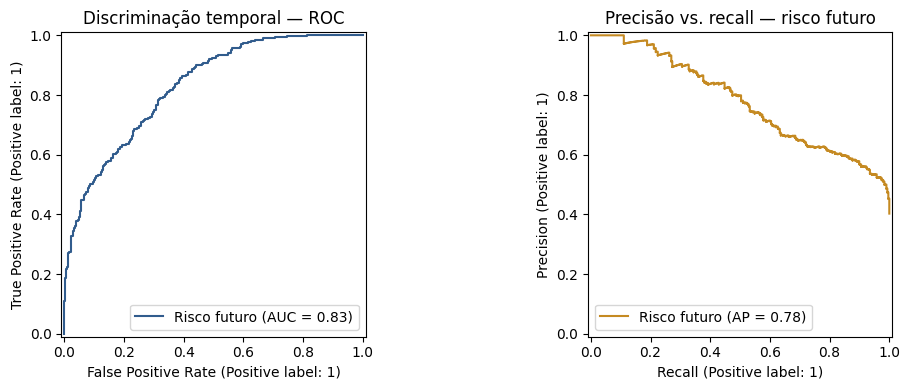

Resposta operacional: os valores acima descrevem a generalização de 2022→2023 para 2023→2024; não representam impacto causal.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_risco, p_risco, name="Risco futuro", ax=axes[0], curve_kwargs={"color": "#315C8D"})
PrecisionRecallDisplay.from_predictions(y_risco, p_risco, name="Risco futuro", ax=axes[1], curve_kwargs={"color": "#C58A22"})
axes[0].set_title("Discriminação temporal — ROC")
axes[1].set_title("Precisão vs. recall — risco futuro")
plt.tight_layout()
plt.show()
print("Resposta operacional: os valores acima descrevem a generalização de 2022→2023 para 2023→2024; não representam impacto causal.")

In [5]:
limiares_risco[["limiar", "taxa_alerta", "precision", "recall", "f1", "falsos_negativos", "falsos_positivos"]].round(3)

,limiar,taxa_alerta,precision,recall,f1,falsos_negativos,falsos_positivos
0,0.2,0.531,0.611,0.805,0.695,60,158
1,0.3,0.416,0.664,0.685,0.674,97,107
2,0.4,0.341,0.713,0.604,0.654,122,75
3,0.5,0.278,0.765,0.529,0.626,145,50
4,0.6,0.221,0.822,0.451,0.583,169,30
5,0.7,0.169,0.860,0.360,0.508,197,18
6,0.8,0.106,0.938,0.247,0.391,232,5


### 2. Incidência de nova defasagem

Este problema é mais próximo de “entrar em risco”, pois remove estudantes já defasados no ano de features. A prevalência, a amostra e a dificuldade estatística mudam; portanto, suas métricas não devem ser comparadas diretamente às do risco futuro.

In [6]:
y_incidencia, p_incidencia, metricas_incidencia, limiares_incidencia = avaliar_modelo(ALVO_INCIDENCIA)
metricas_incidencia.round(3)

,Modelo,n,prevalencia,limiar,taxa_alerta,precision,recall,f1,roc_auc,pr_auc,brier,falsos_negativos,falsos_positivos
0,Baseline (prevalência),370,0.227,0.5,0.000,0.000,0.000,0.00,0.50,0.227,0.184,84,0
1,Regressão logística,370,0.227,0.5,0.314,0.293,0.405,0.34,0.64,0.277,0.261,50,82


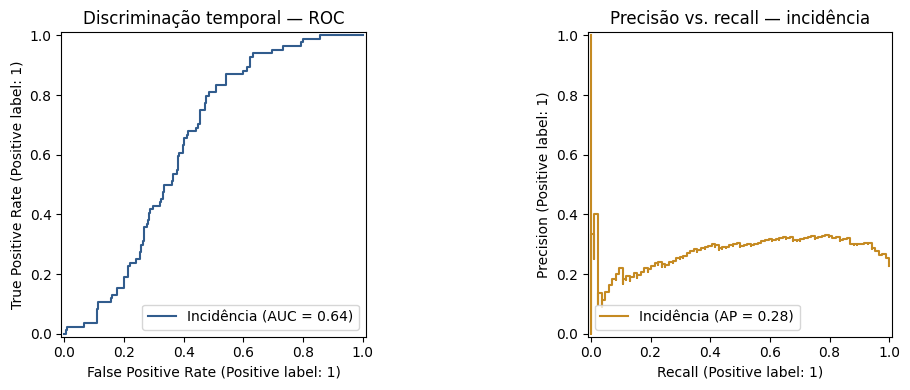

Resposta operacional: o modelo de incidência deve ser usado apenas se o fluxo da Passos Mágicos priorizar prevenção de novos casos.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_incidencia, p_incidencia, name="Incidência", ax=axes[0], curve_kwargs={"color": "#315C8D"})
PrecisionRecallDisplay.from_predictions(y_incidencia, p_incidencia, name="Incidência", ax=axes[1], curve_kwargs={"color": "#C58A22"})
axes[0].set_title("Discriminação temporal — ROC")
axes[1].set_title("Precisão vs. recall — incidência")
plt.tight_layout()
plt.show()
print("Resposta operacional: o modelo de incidência deve ser usado apenas se o fluxo da Passos Mágicos priorizar prevenção de novos casos.")

In [8]:
limiares_incidencia[["limiar", "taxa_alerta", "precision", "recall", "f1", "falsos_negativos", "falsos_positivos"]].round(3)

,limiar,taxa_alerta,precision,recall,f1,falsos_negativos,falsos_positivos
0,0.2,0.511,0.312,0.702,0.432,25,130
1,0.3,0.422,0.301,0.560,0.392,37,109
2,0.4,0.365,0.296,0.476,0.365,44,95
3,0.5,0.314,0.293,0.405,0.340,50,82
4,0.6,0.278,0.262,0.321,0.289,57,76
5,0.7,0.235,0.230,0.238,0.234,64,67
6,0.8,0.165,0.180,0.131,0.152,73,50


## Interpretação e limites

- O teste é temporal e nunca mistura registros de 2022 e 2023 no treino; essa é a avaliação principal desta base curta.
- O ano de 2024 não entra no treino porque não possui alvo 2025.
- O baseline e a regressão logística são pontos de referência; não há comparação de múltiplos algoritmos nem otimização extensa em cima do teste temporal.
- Um limiar de alerta só deve ser escolhido após definir capacidade de atendimento e custo relativo de falsos negativos e falsos positivos.
- Antes de persistir um modelo para o app, a equipe deve congelar o alvo de produto e executar validação adicional no conjunto de treino, sem usar a coorte de teste para escolher parâmetros.

## Próximos passos

1. Definir com o grupo se o aplicativo exibirá risco futuro, incidência ou ambos.
2. Definir capacidade operacional e regra para escolha do limiar de alerta.
3. Fazer seleção de hiperparâmetros somente dentro de 2022 por validação cruzada estratificada; preservar 2023 como teste temporal final.
4. Avaliar calibração e, se necessária, calibrar apenas dentro do treino.
5. Persistir o pipeline aprovado com metadados de versão e construir o app Streamlit.